# 0.Behaviour Utils — Example Workflow

This notebook demonstrates the full behav_utils pipeline using synthetic
data. No real data needed — anyone can run this.

**What you'll see:**
1. Generating synthetic behavioural data (with and without a model)
2. Computing summary statistics at every level
3. Building feature matrices across sessions
4. Plotting psychometric curves, trial rasters, trajectories
5. Multi-animal analysis and the query API
6. Adding a custom summary statistic
7. Plugging in your own model as a simulator

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from behav_utils import (
    generate_synthetic_animal,
    sample_stimuli,
    ExperimentData,
)
from behav_utils.data.synthetic import (
    noisy_psychometric_simulator,
    random_choice_simulator,
)
from behav_utils.analysis import (
    compute_summary_stats,
    list_available_stats,
    fit_psychometric,
    compute_update_matrix,
    build_feature_matrix,
)
from behav_utils.plotting import (
    plot_psychometric,
    plot_stat_trajectory,
    plot_multi_animal_trajectory,
    apply_style,
    COLOURS,
)
from behav_utils.plotting.session import plot_session_trials
from behav_utils.plotting.update_matrix import (
    plot_update_matrix,
    plot_sd_profile,
    plot_update_matrix_summary,
)

apply_style()
print(f"Available stats: {list_available_stats()}")
print(f"\n{len(list_available_stats())} stats registered")

Available stats: ['accuracy', 'psychometric', 'recency', 'win_stay', 'win_stay_rate', 'lose_shift', 'choice_autocorr', 'side_bias', 'stimulus_sensitivity', 'choice_entropy', 'perseveration', 'logistic_history', 'hard_easy_ratio', 'hard_accuracy', 'easy_accuracy', 'conditional_psychometric', 'update_matrix', 'psychometric_gof', 'stimulus_recency', 'recency_divergence', 'history_interaction_r2', 'sd_profile', 'binned_accuracy', 'binned_choice_prob']

24 stats registered


---

## 1. Generate Synthetic Data

behav_utils separates data generation from modelling. You provide
a simulator callable; the library handles stimulus generation and
data structure assembly.

In [2]:
# ── Simple: random choices (for pipeline testing) ────────────────────────
animal_random, info = generate_synthetic_animal(
    animal_id='RAND01',
    n_sessions=15,
    trials_per_session=250,
    simulator=random_choice_simulator,
    simulator_kwargs={'accuracy': 0.65},
    seed=42,
)
print(f"Random animal: {animal_random.n_sessions} sessions, "
      f"{animal_random.sessions[0].trials.n_trials} trials each")

Random animal: 15 sessions, 250 trials each


In [3]:
# ── Psychometric: proper sigmoidal choices ───────────────────────────────
animal_psych, info = generate_synthetic_animal(
    animal_id='PSY01',
    n_sessions=20,
    trials_per_session=300,
    simulator=noisy_psychometric_simulator,
    simulator_kwargs={'sigma': 0.25, 'lapse': 0.05},
    seed=123,
)
print(f"Psychometric animal: {animal_psych.n_sessions} sessions")

Psychometric animal: 20 sessions


In [4]:
# ── Learning trajectory: sigma decreases across sessions ─────────────────
n_sess = 25
animal_learning, info = generate_synthetic_animal(
    animal_id='LEARN01',
    n_sessions=n_sess,
    trials_per_session=300,
    simulator=noisy_psychometric_simulator,
    per_session_simulator_kwargs=[
        {'sigma': 0.8 - i * 0.025, 'lapse': max(0.01, 0.15 - i * 0.005)}
        for i in range(n_sess)
    ],
    seed=456,
)
print(f"Learning animal: {animal_learning.n_sessions} sessions")
print(f"  First session sigma: 0.80, last session sigma: {0.8 - (n_sess-1)*0.025:.2f}")

Learning animal: 25 sessions
  First session sigma: 0.80, last session sigma: 0.20


---

## 2. Session-Level Inspection

Every `SessionData` object has methods for stats and plotting.

In [5]:
# Pick a session
session = animal_learning.sessions[20]  # late session (expert-ish)

# Quick summary
print("Session summary:")
for k, v in session.summary().items():
    print(f"  {k}: {v}")

Session summary:
  session_id: LEARN01_S020
  session_idx: 20
  date: 2025-01-21
  stage: Full_Task_Cont
  distribution: Unknown
  n_trials: 300
  n_valid: 287
  n_abort: 13
  perf: 0.8432055749128919


In [6]:
# Summary stats via data class method
stats = session.stats(['accuracy', 'recency', 'psychometric',
                        'choice_entropy', 'win_stay', 'side_bias'])

print("\nSession stats:")
for k, v in stats.items():
    if isinstance(v, dict):
        for k2, v2 in v.items():
            print(f"  {k2}: {v2:.4f}" if isinstance(v2, float) else f"  {k2}: {v2}")
    else:
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


Session stats:
  accuracy: 0.8432
  recency: -0.0206
  pse: 0.0445
  slope: 0.3234
  lapse_low: 0.0575
  lapse_high: 0.0393
  choice_entropy: 0.5726
  win_stay: 0.0147
  side_bias: -0.0052


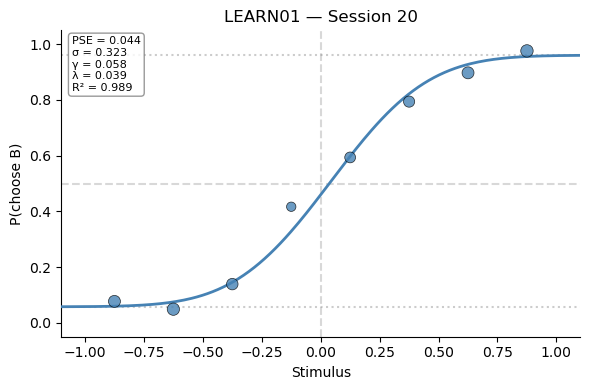

In [7]:
# Psychometric curve — via data class
fig, ax, info = session.plot_psychometric(
    show_params=True, show_gof=True, show_lapse=True,
)
ax.set_title(f'{animal_learning.animal_id} — Session {session.session_idx}')
plt.tight_layout()
plt.show()

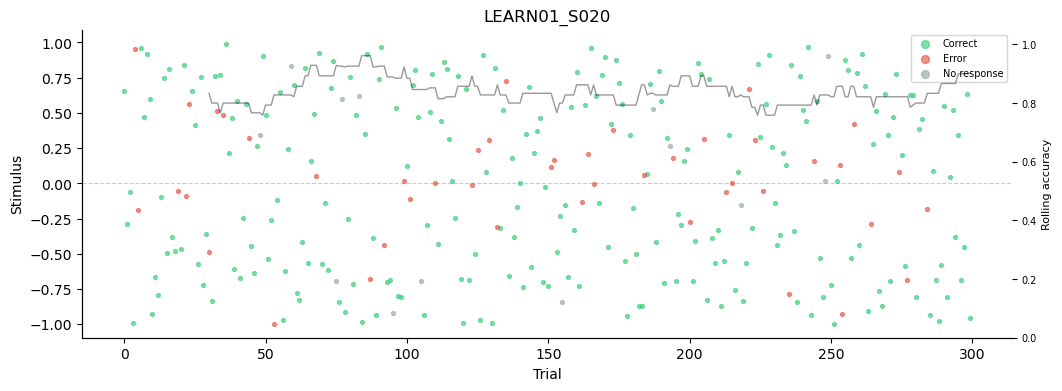

In [8]:
# Trial raster
fig, ax = plot_session_trials(session, window=30)
plt.show()

In [9]:
# The same stats via standalone function (raw arrays)
arrays = session.trials.get_arrays()
valid = ~arrays['no_response']

stats_raw = compute_summary_stats(
    arrays['choices'][valid],
    arrays['stimuli'][valid],
    arrays['categories'][valid],
    stat_names=['accuracy', 'recency'],
    return_dict=True,
)
print(f"Standalone stats: {stats_raw}")
print("(Same result, different access pattern)")

Standalone stats: {'accuracy': 0.8432055749128919, 'recency': np.float64(-0.020603925023246705)}
(Same result, different access pattern)


---

## 3. Update Matrix (Serial Dependence)

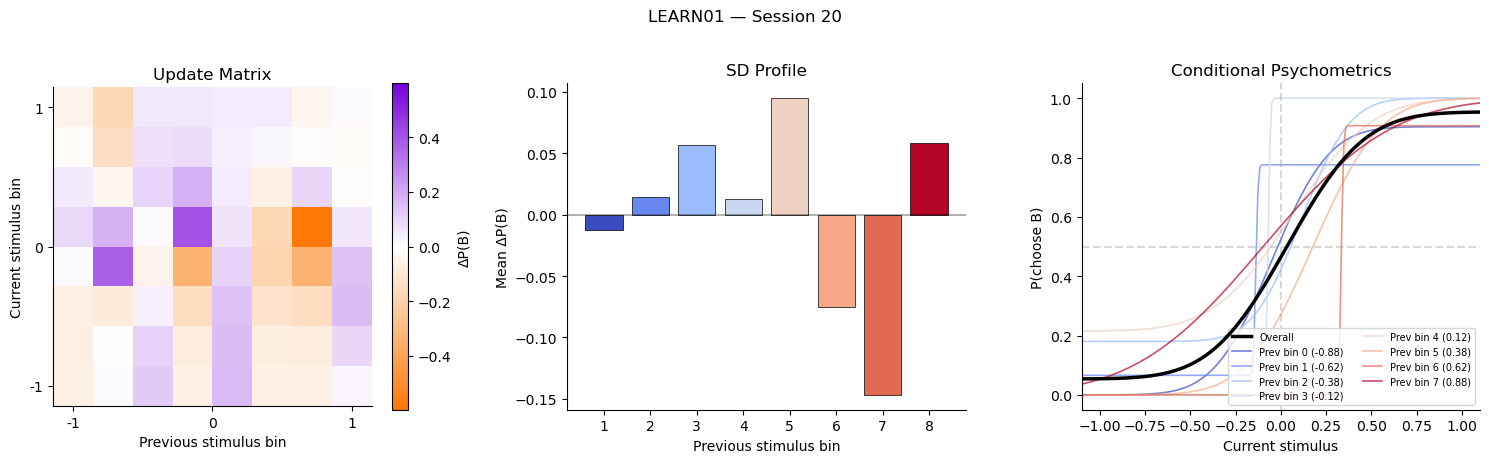

In [10]:
# Compute update matrix for the expert session
arrays = session.trials.get_arrays()
valid = ~arrays['no_response']

um, cm, info = compute_update_matrix(
    arrays['stimuli'][valid],
    arrays['choices'][valid],
    arrays['categories'][valid],
)

# Three-panel summary: matrix + profile + conditional psychometrics
fig, axes = plot_update_matrix_summary(
    um, cm, info,
    title=f'{animal_learning.animal_id} — Session {session.session_idx}',
)
plt.show()

---

## 4. Animal-Level Analysis

Feature matrix, stat trajectories, and multi-session psychometric plots.

In [11]:
# Feature matrix: all stats x all sessions
df = animal_learning.feature_matrix()
print(f"Feature matrix: {len(df)} sessions x {len(df.columns)} columns")
print(f"\nFirst few columns: {list(df.columns[:15])}")
df[['session_idx', 'accuracy', 'pse', 'slope', 'recency',
    'choice_entropy', 'side_bias']].head(10)

Feature matrix: 25 sessions x 151 columns

First few columns: ['animal_id', 'session_id', 'session_idx', 'date', 'stage', 'distribution', 'n_trials_total', 'n_trials_valid', 'n_trials_abort', 'abort_rate', 'accuracy', 'pse', 'slope', 'lapse_low', 'lapse_high']


,session_idx,accuracy,pse,slope,recency,choice_entropy,side_bias
0,0,0.651568,-0.458779,0.627126,0.054706,0.884234,-0.012195
1,1,0.608997,0.669146,0.700016,0.063514,0.921753,-0.019031
2,2,0.671329,-0.118293,0.338190,-0.102247,0.877735,-0.006993
3,3,0.648276,0.176165,0.247277,0.052443,0.865823,-0.075862
4,4,0.703571,-0.049992,0.399523,0.015461,0.839955,0.021429
5,5,0.752650,-0.029423,0.172491,-0.034118,0.767610,-0.030035
6,6,0.683099,-0.011878,0.595444,-0.060040,0.817112,-0.003521
7,7,0.711806,-0.259283,0.491814,0.012855,0.835833,0.020833
8,8,0.719298,-0.092020,0.718149,0.083503,0.761344,0.022807
9,9,0.740484,-0.241048,0.393418,0.006752,0.738959,-0.012111


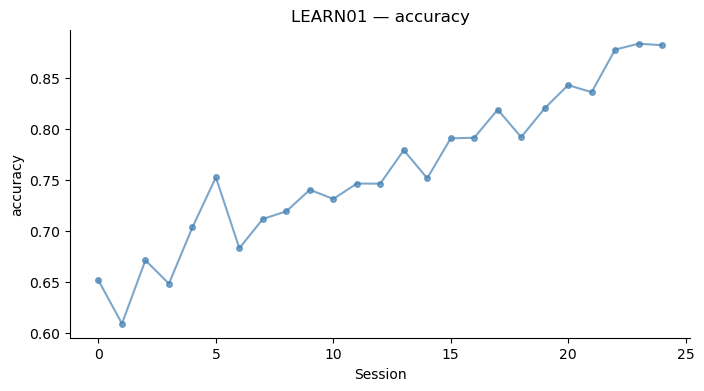

In [12]:
# Stat trajectory — via data class
fig, ax = animal_learning.plot_trajectory('accuracy')
plt.show()

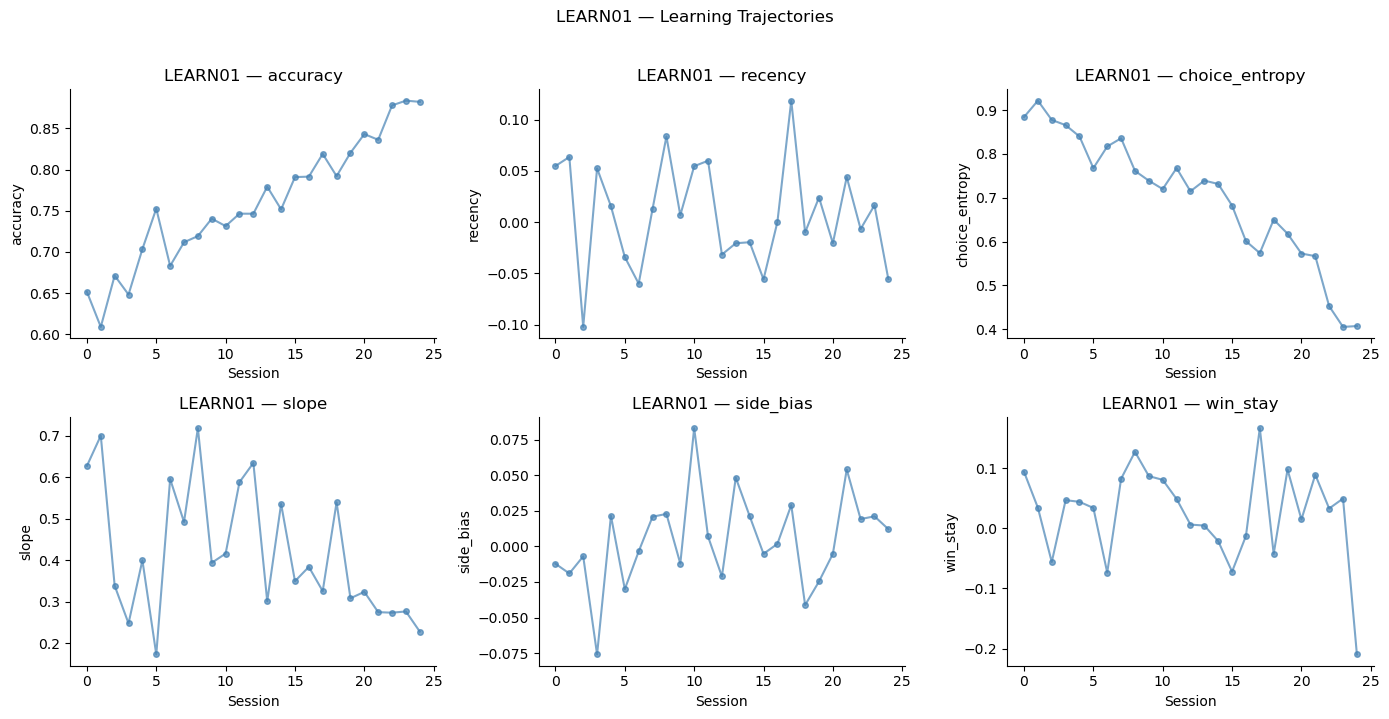

In [13]:
# Multiple stats
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, stat in zip(axes.flatten(),
                     ['accuracy', 'recency', 'choice_entropy',
                      'slope', 'side_bias', 'win_stay']):
    try:
        animal_learning.plot_trajectory(stat, ax=ax)
    except Exception:
        ax.set_title(f'{stat} (not available)')

plt.suptitle(f'{animal_learning.animal_id} — Learning Trajectories',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

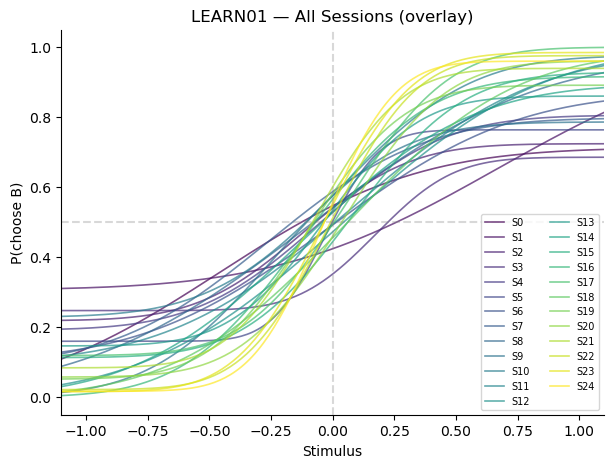

In [14]:
# Psychometric evolution: overlay mode
fig, ax, infos = animal_learning.plot_psychometric(
    sessions='all', mode='overlay',
)
ax.set_title(f'{animal_learning.animal_id} — All Sessions (overlay)')
plt.show()

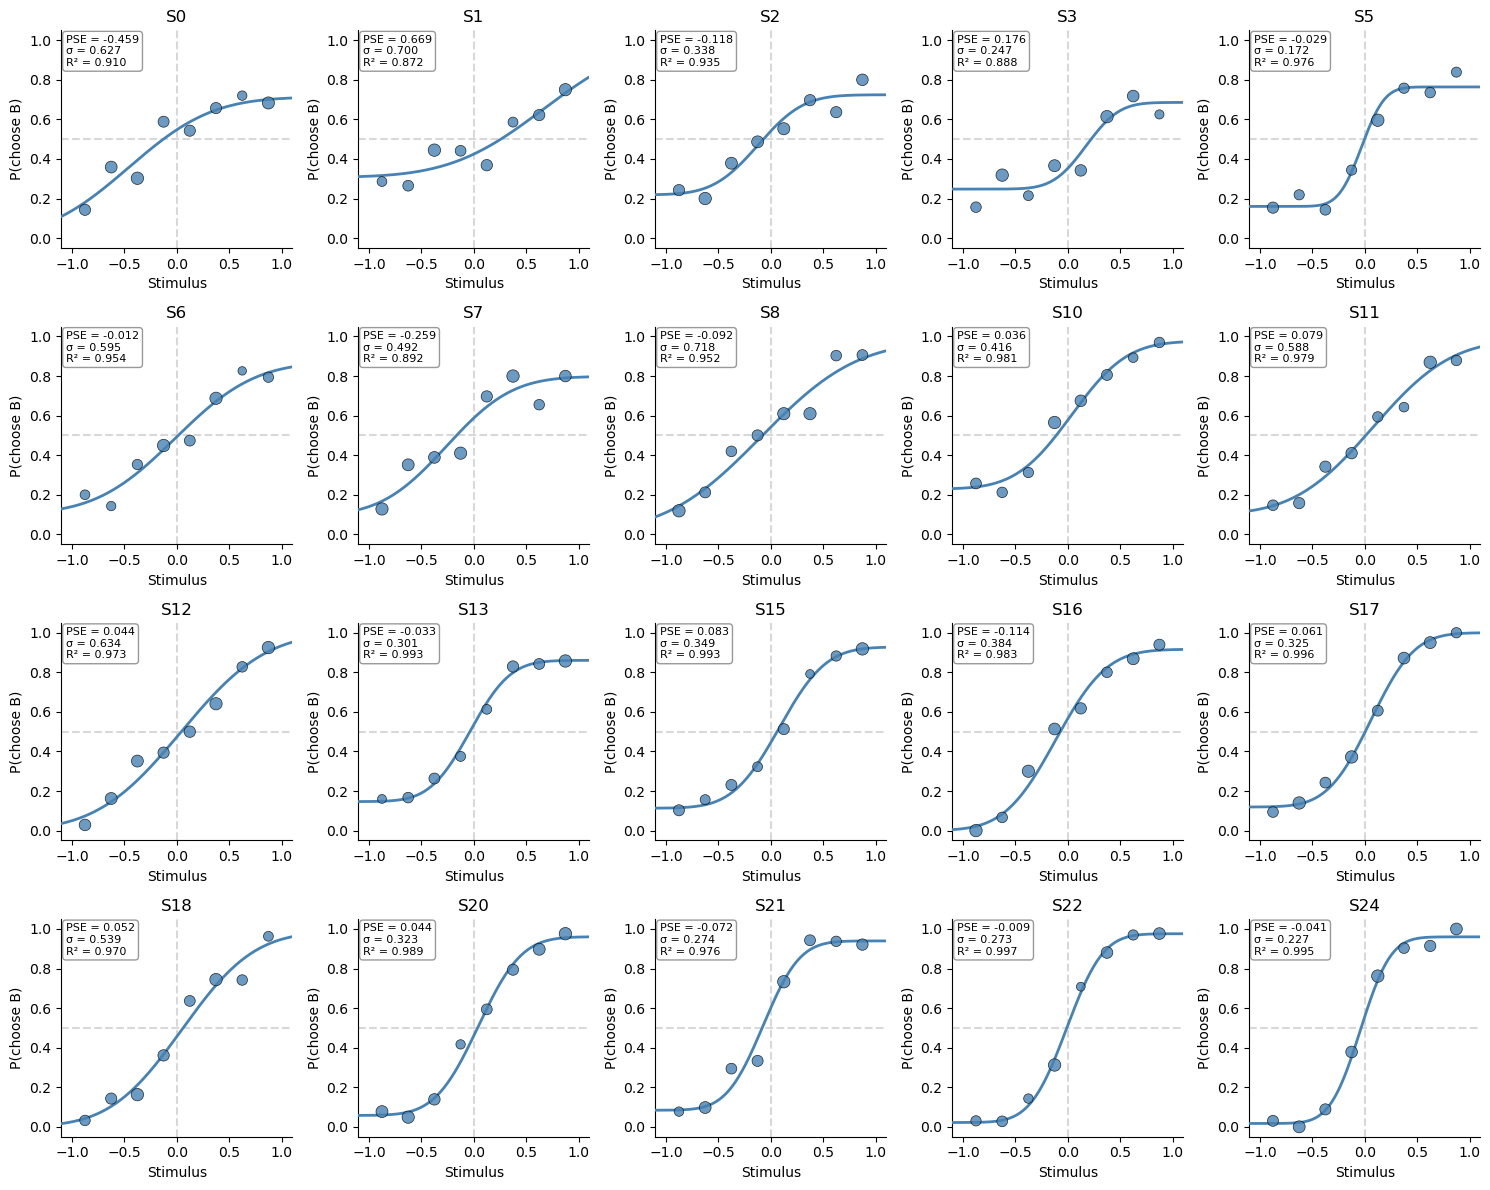

In [15]:
# Grid mode: one panel per session (evenly sampled)
fig, axes, infos = animal_learning.plot_psychometric(
    sessions='all', mode='grid',
)
plt.show()

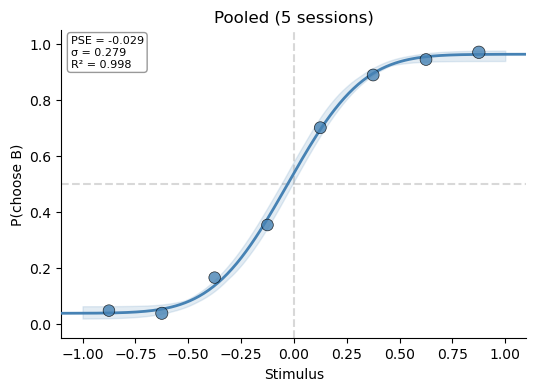

In [29]:
# Pooled: last 5 sessions combined
fig, ax, info = animal_learning.plot_psychometric(
    sessions='last_5', mode='pooled',
    n_bootstrap=10, show_ci=True
)
plt.show()

In [30]:
# Expert baseline
baseline = animal_learning.expert_baseline(
    ['accuracy', 'recency', 'choice_entropy', 'slope'],
    last_n=5,
)
print("Expert baseline (last 5 sessions):")
for feat, vals in baseline.items():
    print(f"  {feat}: mean={vals['mean']:.3f}, std={vals['std']:.3f}")

Expert baseline (last 5 sessions):
  accuracy: mean=0.865, std=0.023
  recency: mean=-0.005, std=0.038
  choice_entropy: mean=0.481, std=0.083
  slope: mean=0.275, std=0.034


In [18]:
# Flexible trial data extraction
data = animal_learning.get_trial_data(
    fields=['stimuli', 'choices', 'categories', 'reaction_times'],
)
print(f"Extracted {data['n_sessions']} sessions")
print(f"Trials per session: {data['trials_per_session']}")

Extracted 25 sessions
Trials per session: [287 289 286 290 280 283 284 288 285 289 283 288 284 290 282 287 283 293
 279 284 287 287 287 284 289]


---

## 5. Multi-Animal (Experiment-Level)

The query API works across animals with filtering and aggregation.

In [19]:
# Create a small experiment with multiple animals
experiment = ExperimentData()

for i in range(5):
    n_sess = 20
    animal, _ = generate_synthetic_animal(
        animal_id=f'ANIMAL_{i+1:02d}',
        n_sessions=n_sess,
        trials_per_session=250,
        simulator=noisy_psychometric_simulator,
        per_session_simulator_kwargs=[
            {'sigma': 0.7 - j * 0.025 + np.random.normal(0, 0.02),
             'lapse': max(0.01, 0.12 - j * 0.004)}
            for j in range(n_sess)
        ],
        seed=100 + i,
    )
    experiment.add_animal(animal)

print(f"Experiment: {experiment.n_animals} animals")
experiment.summary()

Experiment: 5 animals


,animal_id,n_sessions,stages,date_first,date_last
0,ANIMAL_01,20,[Full_Task_Cont],2025-01-01,2025-01-20
1,ANIMAL_02,20,[Full_Task_Cont],2025-01-01,2025-01-20
2,ANIMAL_03,20,[Full_Task_Cont],2025-01-01,2025-01-20
3,ANIMAL_04,20,[Full_Task_Cont],2025-01-01,2025-01-20
4,ANIMAL_05,20,[Full_Task_Cont],2025-01-01,2025-01-20


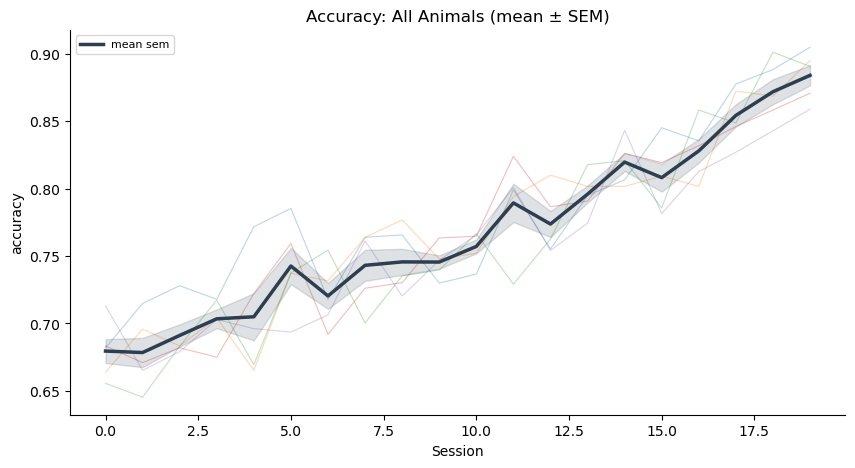

In [20]:
# Query API: trajectory across all animals with mean ± SEM
fig, ax = experiment.plot_trajectory(
    stat='accuracy',
    combine='mean_sem',
)
ax.set_title('Accuracy: All Animals (mean \u00b1 SEM)')
plt.show()

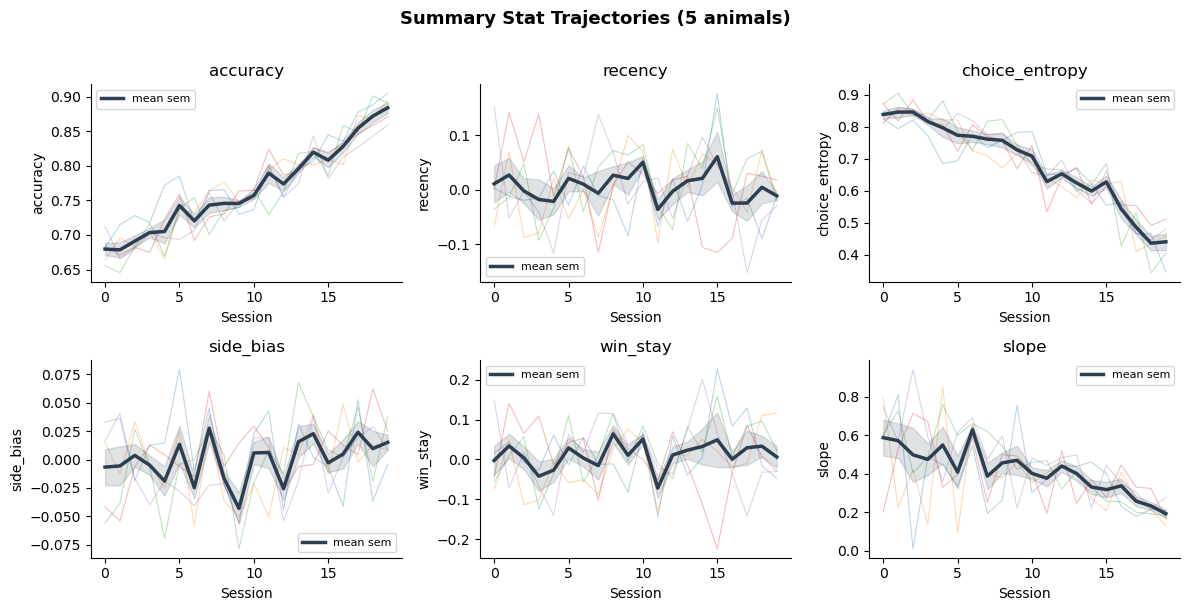

In [21]:
# Multiple stats, group level
from behav_utils.plotting.trajectory import plot_stat_grid

animals = experiment.get_animals(min_sessions=10)
fig, axes = plot_stat_grid(
    animals,
    stats=['accuracy', 'recency', 'choice_entropy',
           'side_bias', 'win_stay', 'slope'],
    combine='mean_sem',
    n_cols=3,
)
plt.show()

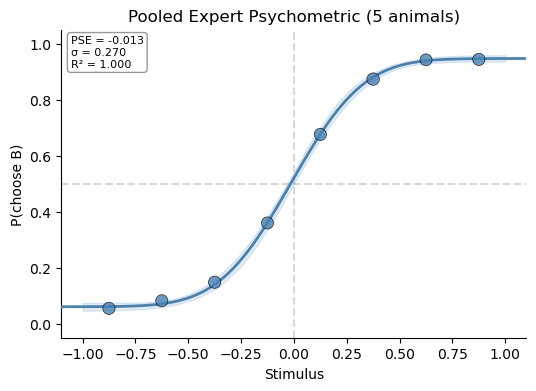

In [22]:
# Pooled psychometric from all animals, last 5 sessions
fig, ax, info = experiment.plot_psychometric(
    sessions='last_5', mode='pooled',
)
ax.set_title(f'Pooled Expert Psychometric ({experiment.n_animals} animals)')
plt.show()

In [23]:
# Pooled feature matrix
df_all = experiment.feature_matrix(min_sessions=10)
print(f"Pooled feature matrix: {len(df_all)} sessions from "
      f"{df_all['animal_id'].nunique()} animals")

Pooled feature matrix: 100 sessions from 5 animals


---

## 6. Adding a Custom Statistic

Use `@register_stat` to add your own. It's immediately available
everywhere — `session.stats()`, feature matrices, etc.

In [24]:
from behav_utils.analysis.summary_stats import register_stat

@register_stat('extreme_choice_rate')
def compute_extreme_choice_rate(choices, stimuli, categories):
    """
    Proportion of choices made on the easiest trials (|stimulus| > 0.8).
    High = animal engages with easy trials. Low = many aborts on easy trials.
    """
    valid = ~np.isnan(choices)
    if valid.sum() < 10:
        return np.nan
    extreme = np.abs(stimuli[valid]) > 0.8
    if extreme.sum() == 0:
        return np.nan
    return float(np.mean(choices[valid][extreme] == categories[valid][extreme]))

# Now usable everywhere
session = animal_learning.sessions[-1]
stats = session.stats(['accuracy', 'extreme_choice_rate'])
print(f"accuracy: {stats['accuracy']:.3f}")
print(f"extreme_choice_rate: {stats['extreme_choice_rate']:.3f}")
print(f"\nTotal registered stats: {len(list_available_stats())}")

accuracy: 0.882
extreme_choice_rate: 0.982

Total registered stats: 25


---

## 7. Plugging In Your Own Model

Any function with signature `(stimuli, categories, rng, **kwargs) -> choices`
works as a simulator. The library doesn't know about your model — it just
calls the function and wraps the output in data classes.

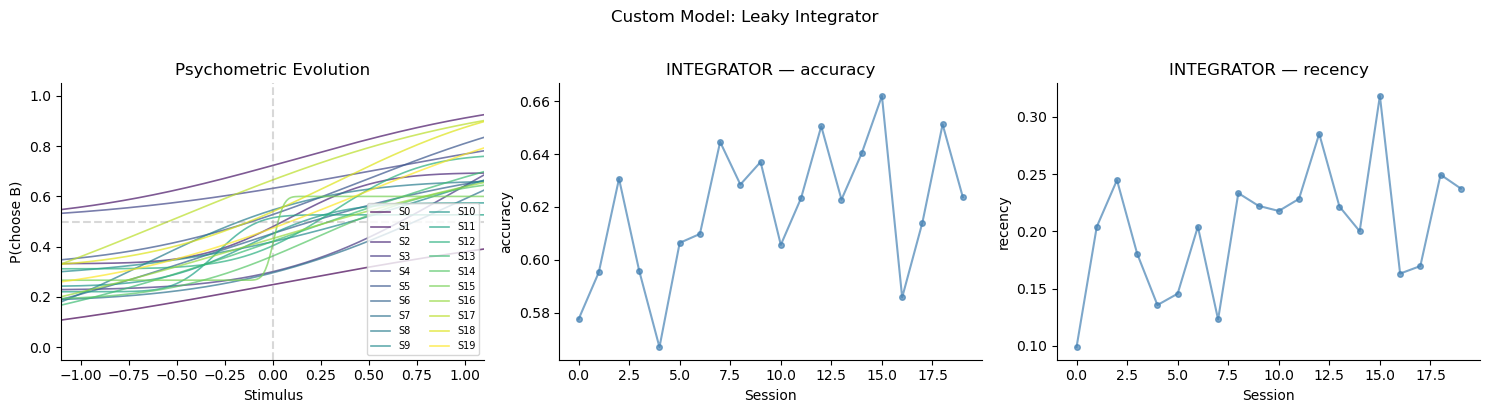

In [25]:
# A simple leaky integrator model
def leaky_integrator_simulator(stimuli, categories, rng,
                                leak=0.1, noise=0.3, threshold=0.5, **kwargs):
    """
    Leaky integrator: accumulates evidence with leak and noise.
    Choice = which side of threshold the accumulator is on.
    """
    n = len(stimuli)
    choices = np.full(n, np.nan)
    state = 0.0  # internal accumulator

    for t in range(n):
        # Leak toward zero
        state *= (1 - leak)
        # Accumulate stimulus + noise
        state += stimuli[t] + rng.normal(0, noise)
        # Decision
        choices[t] = 1.0 if state > 0 else 0.0

    return choices

# Generate animal with learning trajectory (decreasing noise)
n_sess = 20
animal_integrator, info = generate_synthetic_animal(
    animal_id='INTEGRATOR',
    n_sessions=n_sess,
    trials_per_session=300,
    simulator=leaky_integrator_simulator,
    per_session_simulator_kwargs=[
        {'leak': 0.1, 'noise': 0.6 - i * 0.02}
        for i in range(n_sess)
    ],
    seed=789,
)

# Full analysis — works identically to any other animal
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Psychometric evolution
animal_integrator.plot_psychometric(sessions='all', mode='overlay', ax=axes[0])
axes[0].set_title('Psychometric Evolution')

# Accuracy trajectory
animal_integrator.plot_trajectory('accuracy', ax=axes[1])

# Recency trajectory
animal_integrator.plot_trajectory('recency', ax=axes[2])

plt.suptitle('Custom Model: Leaky Integrator', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---

## 8. Standalone Function Access

Every analysis and plotting function works without data classes.
Just pass raw numpy arrays.

Accuracy: 0.780


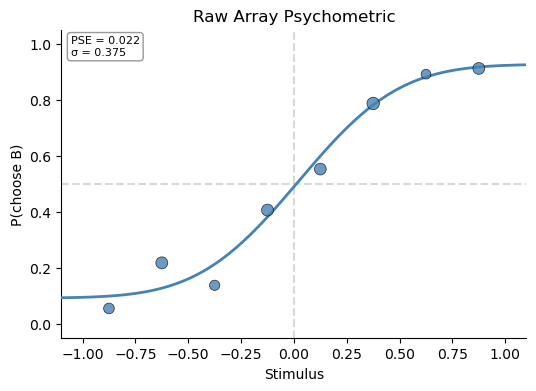

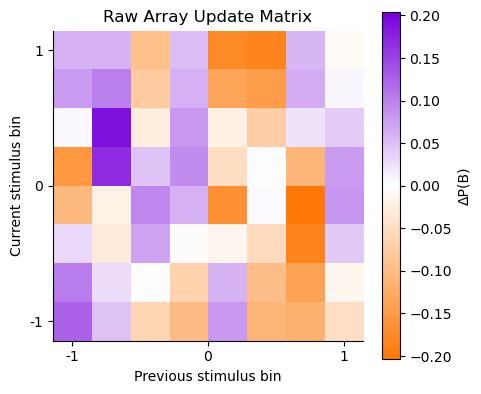

In [26]:
# Generate raw arrays
stimuli, categories = sample_stimuli(500)
rng = np.random.default_rng(42)
p_b = 0.05 + 0.9 * (1 / (1 + np.exp(-stimuli / 0.25)))
choices = (rng.random(500) < p_b).astype(float)

# Stats on raw arrays
stats = compute_summary_stats(
    choices, stimuli, categories,
    stat_names=['accuracy', 'recency', 'psychometric'],
    return_dict=True,
)
print(f"Accuracy: {stats['accuracy']:.3f}")

# Plot on raw arrays
fig, ax, info = plot_psychometric(stimuli, choices, title='Raw Array Psychometric')
plt.show()

# Update matrix on raw arrays
um, cm, info = compute_update_matrix(stimuli, choices, categories)
fig, ax = plot_update_matrix(um, title='Raw Array Update Matrix')
plt.show()

---

## Summary

This notebook demonstrated:

- **Synthetic data**: `generate_synthetic_animal` with built-in or custom simulators
- **Session-level**: `session.stats()`, `session.plot_psychometric()`, `plot_session_trials()`
- **Animal-level**: `animal.feature_matrix()`, `animal.plot_trajectory()`, `animal.plot_psychometric()`
- **Experiment-level**: `experiment.plot_trajectory(combine='mean_sem')`, `experiment.feature_matrix()`
- **Custom stats**: `@register_stat` for instant integration
- **Custom models**: any `(stimuli, categories, rng, **kwargs) -> choices` callable
- **Standalone access**: all functions work on raw numpy arrays without data classes

For real data, create a `config.yaml` mapping your CSV columns and use
`load_experiment('config.yaml')` — everything else works the same.